---
title: "Lecture 14: Finite differences"
author: "Jamie Haddock"
format: 
    revealjs:
        output-file: Lecture14_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
    html: 
        code-fold: true
        embed-resources: true
    pdf:
        documentclass: article
        toc: true
        number-sections: true
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: julia-1.9
filters: 
  - input/remove-pause.lua
execute:
  echo: true
  eval: true
---

# Finite differences

One of the most common applications of interpolants is numerical differentiation -- approximating the derivative of a function.

. . .

::: {.callout-note icon=false}
## Definition: Finite-difference formula
A **finite-difference** formula is a list of values $a_{-p}, \cdots, a_q$, called **weights**, such that for all $f$ in some class of functions, $$f'(x) \approx \frac{1}{h} \sum_{k=-p}^q a_k f(x + kh).$$  The weights are independent of $f$ and $h$.  The formula is said to be **convergent** if the approximation becomes equality in the limit $h \rightarrow 0$ for a suitable class of functions.
:::

. . .

While a finite-difference formula yields a derivative estimate for a single point, typically they are applied for many points simultaneously, using a large evenly spaced grid of points.

## Common examples

::: {.callout-note icon=false}
## Definition: Forward, backward, and centered finite-difference formulas
A **forward difference formula** is a finite-difference formula, $$f'(x) \approx \frac{1}{h} \sum_{k=-p}^q a_k f(x + kh),$$ with $p = 0$, a **backward difference formula** has $q=0$, and a **centered difference formula** has $p=q$.
:::

. . .

Simplest examples:

* When $p = 0$, $q = 1$, and $a_0 = -1$, $a_1 = 1$, we have *forward difference formula* $$f'(x) \approx \frac{f(x+h) - f(x)}{h}.$$
* When $p = 1$, $q = 0$, and $a_{-1} = -1, a_0 = 1$, we have *backward difference formula* $$f'(x) \approx \frac{f(x) - f(x-h)}{h}.$$

---

::: {.callout-caution icon=false}
## Exercise: 
Suppose $f(x) = x^2$ and $h = 1/4$ over the interval $[0,1]$, with nodes $0, 1/4, 1/2, 3/4, 1$.  Compute the forward difference estimates at $x = 0, 1/4, 1/2, 3/4$ and the backward difference estimates at $x = 1/4, 1/2, 3/4, 1$.
:::
<details><summary>Answer:</summary> 
We evaluate $f$ at the nodes, $f(0) = 0, f(1/4) = 1/16, f(1/2) = 1/4, f(3/4) = 9/16, f(1) = 1$.  

The forward difference estimates are:

* $f'(0) \approx 4(1/16 - 0)$, $f'(1/4) \approx 4(1/4 - 1/16)$
* $f'(1/2) \approx 4(9/16 - 1/4)$, $f'(3/4) \approx 4(1 - 9/16)$

The backward difference estimates are:

* $f'(1/4) \approx 4(1/16 - 0)$, $f'(1/2) \approx 4(1/4 - 1/16)$
* $f'(3/4) \approx 4(9/16 - 1/4)$, $f'(1) \approx 4(1 - 9/16)$ 
</details>

. . .

Notice that the differences are the same between the forward difference and backward difference estimates but they are interpreted as derivative estimates at different nodes. 

## Centered differences

[The centered difference formula offers a symmetric alternative to forward and backward differences.]{.content-hidden when-format='revealjs' when-format='pptx'} 

For simplicity, let's set $x = 0$.  Note that in this case, the forward difference formula estimates $f'(0)$ as the slope of the line through $(0,f(0))$ and $(h,f(h))$, and the backward difference formula estimates $f'(0)$ as the slope of the line through $(-h,f(-h))$ and $(0,f(0))$. 

[That is, in these cases, we differentiate the interpolation of two points and use this as the derivative estimate.]{.content-hidden when-format='revealjs' when-format='pptx'}  

. . .

Consider now the shortest centered formula with $p = q = 1$.  Here, we have three function values (three nodes) to use, so one option is to interpolate all three points and differentiate this quadratic function, $$Q(x) = \frac{x(x-h)}{2h^2} f(-h) - \frac{x^2 - h^2}{h^2} f(0) + \frac{x(x+h)}{2h^2}f(h).$$  This leads us to a centered difference formula $$f'(0) \approx Q'(0) = \frac{f(h) - f(-h)}{2h}$$ which has $a_{-1} = -1/2$, $a_0 = 0$, and $a_1 = 1/2$.

[In principle, we can derive any finite-difference formula in this way -- interpolate nodes points on the graph of the function, then differentiate the interpolant exactly.  The main motivation for increasing the number of node points involved in the finite differences formula is the improve the *order of accuracy*, which we will define soon.  ]{.content-hidden when-format='revealjs' when-format='pptx'} 

---

In [27]:
f = x -> exp(sin(x));

h = 0.05
CD2 = (         -f(-h)  +   f(h)         ) / 2h
CD4 = (f(-2h)   -8f(-h) +   8f(h) - f(2h)) / 12h
@show (CD2, CD4);

(CD2, CD4) = (0.9999995835069508, 1.0000016631938748)


In [28]:
FD1 = ( -f(0)   +   f(h)        ) / h
FD2 = (-3f(0)   +  4f(h) - f(2h)) / 2h 
@show (FD1,FD2);

(FD1, FD2) = (1.024983957209069, 1.0000996111012461)


In [29]:
BD1 = (          -f(-h) +  f(0)) / h
BD2 = ( f(-2h) - 4f(-h) + 3f(0)) / 2h 
@show (BD1, BD2);

(BD1, BD2) = (0.9750152098048326, 0.9999120340342049)


## Higher derivatives

To estimate a second (or higher) derivative, you might consider stacking finite differences of finite differences, e.g., $$f''(0) \approx \frac{f(-2h) - 2f(0) + f(2h)}{4h^2}.$$

. . .

However, this uses estimates at $\pm 2h$ rather than the closer values at $\pm h$.  A better tactic is to return to the interpolant and compute an exact second (higher) derivative.

. . .

This yields $$f''(0) \approx \frac{f(-h) - 2f(0) + f(h)}{h^2},$$ which is the simplest **centered second-difference formula**.

## Arbitrary nodes

Equally spaced nodes are a common and convenient situation, but node locations can be arbitrary.  The general form of a finite-difference formula is $$f^{(m)}(0) \approx \sum_{k=0}^r c_{k,m} f(t_k).$$  The weights can be derived from the interpolate/differentiate process, but the algebra is complicated.  However, there is a nice recursive algorithm that can calculate the weights for any desired formula known as **Fornberg's algorithm**.

---

In [42]:
# | echo: false

using LinearAlgebra
import Pkg; Pkg.add("PrettyTables")
using PrettyTables
using Plots

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [31]:
"""
    fdweights(t,m)

Compute weights for the `m`th derivative of a function at zero using values at the nodes in vector `t`.
"""
function fdweights(t,m)
    # Recursion for one weight.
    function weight(t,m,r,k)
        # Inputs
        #   t: vector of nodes
        #   m: order of derivative sought
        #   r: number of nodes to use from t
        #   k: index of node whose weight is found
        if (m<0) || (m>r)        # undefined coeffs must be zero
            c = 0
        elseif (m==0) && (r==0)  # base case of one-point interpolation
            c = 1
        else
            if k<r
                c = (t[r+1]*weight(t,m,r-1,k) - m*weight(t,m-1,r-1,k))/(t[r+1]-t[k+1])
            else
                numer = r > 1 ? prod(t[r]-x for x in t[1:r-1]) : 1
                denom = r > 0 ? prod(t[r+1]-x for x in t[1:r]) : 1
                β = numer/denom 
                c = β*(m*weight(t,m-1,r-1,r-1) - t[r]*weight(t,m,r-1,r-1))
            end
        end
        return c 
    end
    r = length(t) - 1
    w = zeros(size(t))
    return [ weight(t,m,r,k) for k=0:r ]
end

fdweights

In [32]:
t = [ 0.35,0.5,0.57,0.6,0.75 ]    # nodes
f = x -> cos(x^2)
dfdx = x -> -2*x*sin(x^2)
exact_value = dfdx(0.5)

-0.24740395925452294

In [33]:
w = fdweights(t.-0.5,1)

5-element Vector{Float64}:
  -0.5303030303030298
 -21.61904761904763
  45.09379509379508
 -23.333333333333307
   0.38888888888888845

In [34]:
fd_value = dot(w,f.(t))

-0.247307422906135

# Convergence of finite differences

The finite difference formulas converge to the correct value as the spacing $h \rightarrow 0$, but the number of nodes (and function evaluations) grows unbounded.  We want to choose $h$ as large as possible while still achieving acceptable accuracy.

::: {.callout-note icon=false}
## Definition: Truncation error of a finite-difference formula
For the finite-difference method with weights $a_{-p}, \cdots, a_q$, the **truncation error** is $$\tau_f(h) = f'(0) - \frac{1}{h} \sum_{k = -p}^q a_k f(kh).$$  The method is said to be **convergent** if $\tau_f(h) \rightarrow 0$ and $h \rightarrow 0$.
:::

## Example

The forward difference formula $f'(0) \approx \frac{f(h) - f(0)}{h}$ yields 

. . .

\begin{align*}
\tau_f(h) &= f'(0) - \frac{f(h) - f(0)}{h}
\\&= f'(0) - h^{-1}\left[\left(f(0) + h f'(0) + \frac12 h^2 f''(0) + \cdots\right) - f(0)\right]
\\&= -\frac12 h f''(0) + O(h^2).
\end{align*}

. . .

The truncation error is $O(h)$ as $h \rightarrow 0$.

## Order of accuracy

::: {.callout-note icon=false}
## Definition: Order of accuracy of a finite-difference formula
If the truncation error of a finite-difference formula satisfies $\tau_f(h) = O(h^m)$ for a positive integer $m$, then $m$ is the **order of accuracy** of the formula.
:::

. . .

The forward-difference formula $f'(0) \approx \frac{f(h) - f(0)}{h}$ is **first-order accurate**.

In [35]:
f = x -> sin(exp(x+1))
exact_value = exp(1)*cos(exp(1))  # derivative at x = 0

-2.478349732955235

In [40]:
h = [ 5/10^n for n in 1:6 ]
FD1 = []; FD2 = [];
for h in h 
    push!(FD1, (f(h)-f(0)) / h )
    push!(FD2, (f(h)-f(-h)) / 2h )
end

pretty_table([h FD1 FD2],header=["h","FD1","FD2"])

┌────────┬──────────┬──────────┐
│      h │      FD1 │      FD2 │
├────────┼──────────┼──────────┤
│    0.5 │ -2.76858 │ -1.97047 │
│   0.05 │  -2.6128 │ -2.47552 │
│  0.005 │ -2.49211 │ -2.47832 │
│ 0.0005 │ -2.47973 │ -2.47835 │
│ 5.0e-5 │ -2.47849 │ -2.47835 │
│ 5.0e-6 │ -2.47836 │ -2.47835 │
└────────┴──────────┴──────────┘


---

In [41]:
error_FD1 = @. exact_value-FD1
error_FD2 = @. exact_value-FD2
table = [h error_FD1 error_FD2]
pretty_table(table,header=["h","error in FD1","error in FD2"])

┌────────┬──────────────┬──────────────┐
│      h │ error in FD1 │ error in FD2 │
├────────┼──────────────┼──────────────┤
│    0.5 │     0.290226 │    -0.507878 │
│   0.05 │     0.134446 │  -0.00282948 │
│  0.005 │    0.0137555 │  -2.80378e-5 │
│ 0.0005 │   0.00137813 │  -2.80353e-7 │
│ 5.0e-5 │  0.000137838 │  -2.80297e-9 │
│ 5.0e-6 │   1.37841e-5 │  1.53291e-11 │
└────────┴──────────────┴──────────────┘


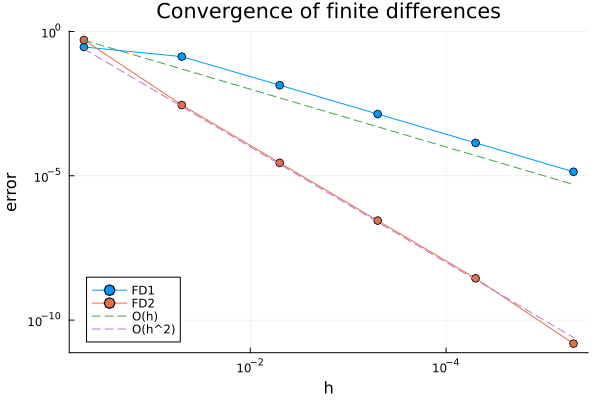

In [44]:
plot(h,abs.([error_FD1 error_FD2]), m=:o,label=["FD1" "FD2"],
    xflip=true,xaxis=(:log10,"h"),yaxis=(:log10,"error"),
    title="Convergence of finite differences",leg=:bottomleft)
plot!(h,[h, h.^2],l=:dash,label=["O(h)" "O(h^2)"])

## Stability

In addition to the truncation error (the planned and understood error), there is round-off error.  Consider the forward difference $$\delta(h) = \frac{f(x+h) - f(x)}{h}.$$

. . .

As $h \rightarrow 0$, the numerator approaches zero even though the values involved are not necessarily near 0.  This is the recipe for subtractive cancellation error!  In fact, these formulas are inherently ill-conditioned as $h \rightarrow 0$.

. . .

Recall that the condition number for the problem of computing $f(x+h) - f(x)$ is $$\kappa(h) = \frac{\max\{|f(x+h)|,|f(x)|\}}{|f(x+h)-f(x)|}.$$  

---

Hence, the numerical value we actually compute for $\delta$ is 

\begin{align*}
\tilde{\delta}(h) &= \frac{f(x+h) - f(x)}{h} (1 + \kappa(h)\epsilon_{\text{mach}})
\\&= \delta(h) + \frac{\max\{|f(x+h)|,|f(x)|\}}{|f(x+h)-f(x)|} \frac{f(x+h) - f(x)}{h} \epsilon_{\text{mach}}
\end{align*}

. . .

As $h \rightarrow 0$,
$$|\tilde{\delta}(h) - \delta(h)| = \frac{\max\{|f(x+h)|,|f(x)|\}}{h} \epsilon_{\text{mach}} \sim |f(x)| \epsilon_{\text{mach}} h^{-1}.$$

. . .

Combining the truncation and roundoff errors yields $$|f'(x) - \tilde{\delta}(h)| \le |\tau_f(h)| + |f(x)| \epsilon_{\text{mach}} h^{-1}.$$  

. . .

As the truncation error decreases as $h$ decreases, the roundoff error actually *increases* due to subtractive cancellation.  

---

At around $h \approx K \sqrt{\epsilon_{\text{mach}}}$, these errors are roughly the same size.  For this first-order finite-difference method, the optimal spacing between nodes is proportional to $\sqrt{\epsilon_{\text{mach}}}$.

. . .

::: {.callout-warning icon=false}
## Fact: 
For computing with a finite-difference method of order $m$ in the presence of roundoff, the optimal spacing of nodes satisfies $$h_{\text{opt}} \approx \epsilon_{\text{mach}}^{1/(m+1)},$$ and the optimal total error is roughly $\epsilon_{\text{mach}}^{m/(m+1)}$.  
:::

. . .

In [45]:
f = x -> exp(-1.3*x);
exact = -1.3

h = [ 1/10^n for n in 1:12 ]
FD1, FD2, FD4 = [], [], []
for h in h 
    nodes = h*(-2:2)
    vals = @. f(nodes)
    push!(FD1, dot([ 0 0 -1 1 0 ]/h,vals))
    push!(FD2, dot([ 0 -1/2 0 1/2 0 ]/h,vals))
    push!(FD4, dot([ 1/12 -2/3 0 2/3 -1/12 ]/h, vals))
end

table = [h FD1 FD2 FD4]
pretty_table(table[1:4,:],header=["h","FD1","FD2","FD4"])

┌────────┬──────────┬──────────┬──────────┐
│      h │      FD1 │      FD2 │      FD4 │
├────────┼──────────┼──────────┼──────────┤
│    0.1 │ -1.21905 │ -1.30366 │ -1.29999 │
│   0.01 │ -1.29159 │ -1.30004 │     -1.3 │
│  0.001 │ -1.29916 │     -1.3 │     -1.3 │
│ 0.0001 │ -1.29992 │     -1.3 │     -1.3 │
└────────┴──────────┴──────────┴──────────┘


---

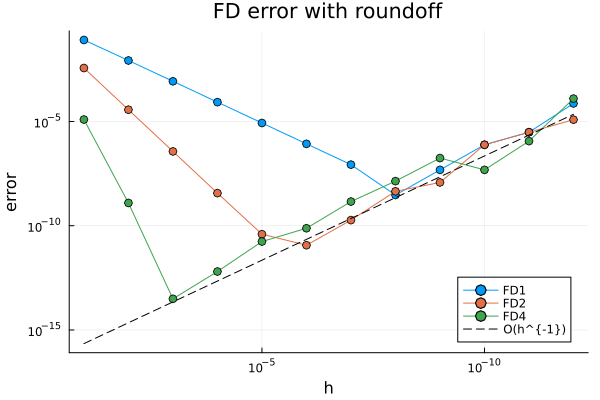

In [46]:
err = @. abs([FD1 FD2 FD4] - exact)

plot(h,err,m=:o,label=["FD1" "FD2" "FD4"],
    xaxis=(:log10,"h"),xflip=true,yaxis=(:log10,"error"), 
    title="FD error with roundoff",legend=:bottomright)

plot!(h,0.1*eps()./h,l=:dash,color=:black,label="O(h^{-1})")

. . .

The error is initially dominated by truncation error, but eventuallly the roundoff error dominates.

<!--
[verbose test]{.content-hidden when-format="revealjs" when-format="pptx"}

::: {.callout-caution icon=false}
## Exercise: 

:::

<details><summary>Answer:</summary> </details>


::: {.callout-note icon=false}
## Definition: 
 
:::


::: {.callout-tip icon=false}
## Note: 
 
:::
-->